# Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Exploring dataset

In [2]:
# Load the dataset
train_file = 'data/customer_churn_dataset-training-master.csv'
test_file = 'data/customer_churn_dataset-testing-master.csv'

df = pd.concat(
    [
        pd.read_csv(train_file), 
        pd.read_csv(test_file)
    ], 
    axis=0)
df.reset_index(drop=True, inplace=True)
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 46.3+ MB


In [4]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


# Removing null values

In [4]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [5]:
df[df.isna().any(axis=1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.dropna(inplace=True)
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505202,64370.0,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
505203,64371.0,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
505204,64372.0,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
505205,64373.0,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


Frequency of churn categories

In [7]:
df['Churn'].value_counts()

Churn
1.0    280492
0.0    224714
Name: count, dtype: int64

# Encoding Data

In [8]:
# Encoding function
def object_to_int(dataframe_series):
    if dataframe_series.dtype == 'object':
        return LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series

df_encoded = df.apply(lambda x: object_to_int(x))
df_encoded.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,0,39.0,14.0,5.0,18.0,2,0,932.0,17.0,1.0
1,3.0,65.0,0,49.0,1.0,10.0,8.0,0,1,557.0,6.0,1.0
2,4.0,55.0,0,14.0,4.0,6.0,18.0,0,2,185.0,3.0,1.0
3,5.0,58.0,1,38.0,21.0,7.0,7.0,2,1,396.0,29.0,1.0
4,6.0,23.0,1,32.0,20.0,5.0,8.0,0,1,617.0,20.0,1.0


# Data visualizing

## Correlation Heatmap

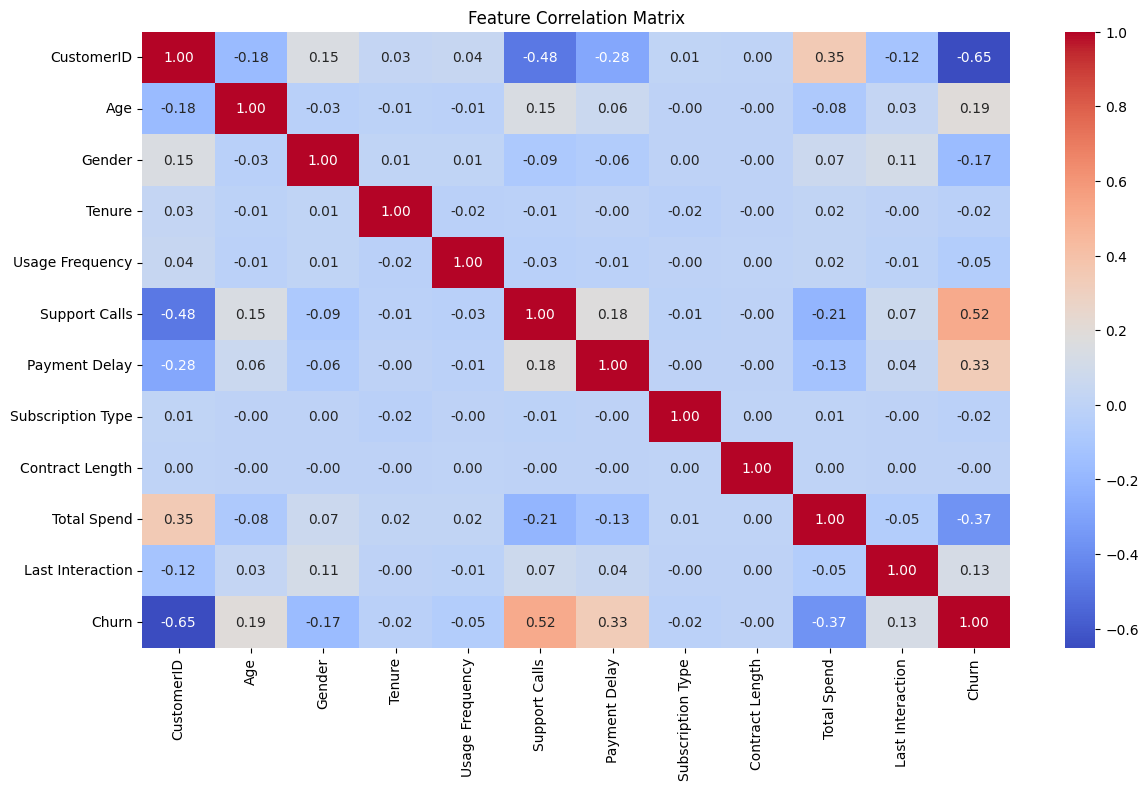

In [9]:
# Correlation Matrix to identify key drivers
plt.figure(figsize=(14, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

## Churn vs stayed distribution

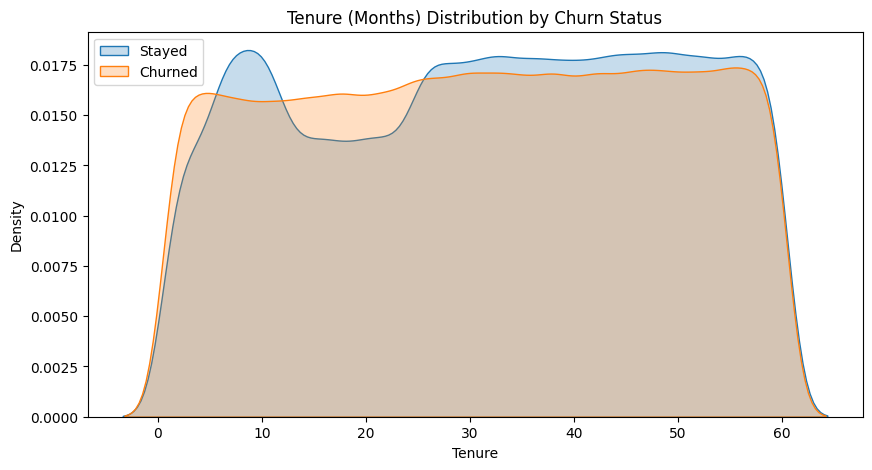

In [10]:
# Visualizing Tenure vs Churn
plt.figure(figsize=(10, 5))
sns.kdeplot(df_encoded[df_encoded['Churn'] == 0]['Tenure'], label='Stayed', fill=True)
sns.kdeplot(df_encoded[df_encoded['Churn'] > 0]['Tenure'], label='Churned', fill=True)
plt.title('Tenure (Months) Distribution by Churn Status')
plt.legend()
plt.show()

## Checking for outliers

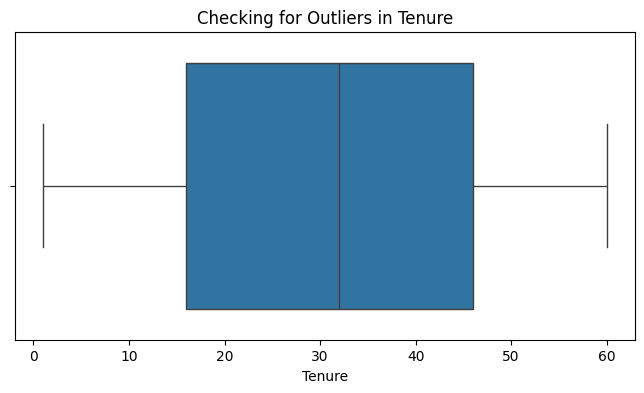

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Tenure'])
plt.title('Checking for Outliers in Tenure')
plt.show()

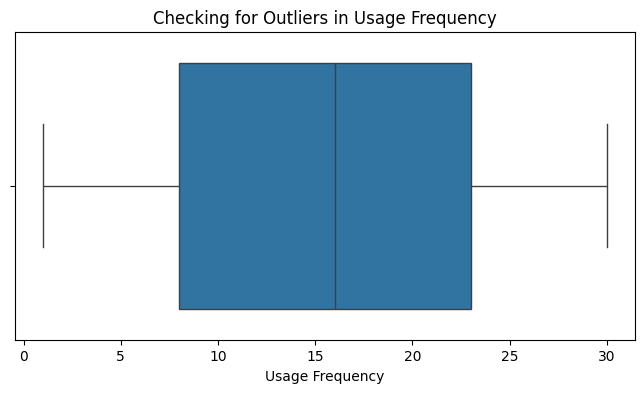

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Usage Frequency'])
plt.title('Checking for Outliers in Usage Frequency')
plt.show()

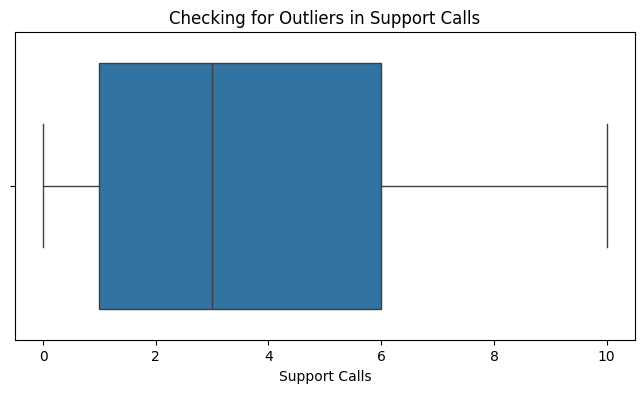

In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Support Calls'])
plt.title('Checking for Outliers in Support Calls')
plt.show()

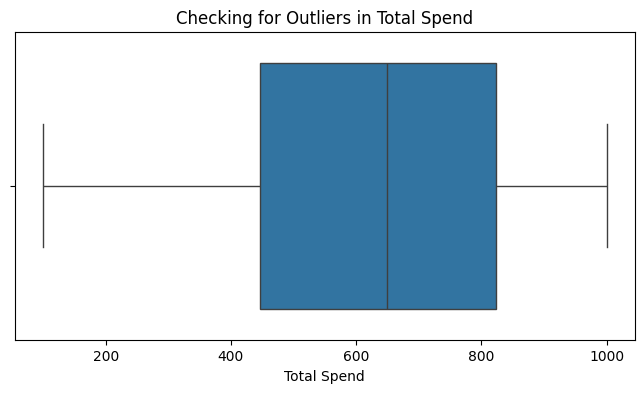

In [16]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Total Spend'])
plt.title('Checking for Outliers in Total Spend')
plt.show()

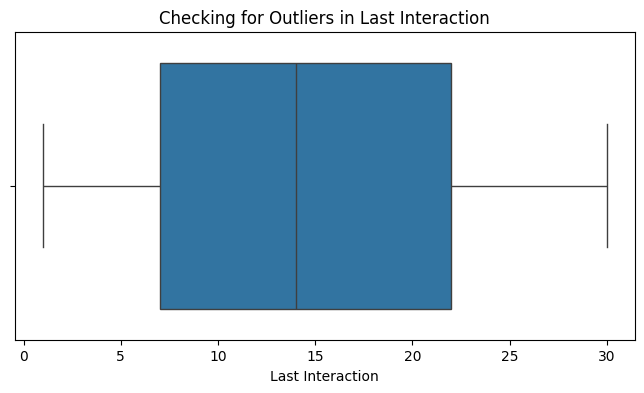

In [17]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Last Interaction'])
plt.title('Checking for Outliers in Last Interaction')
plt.show()

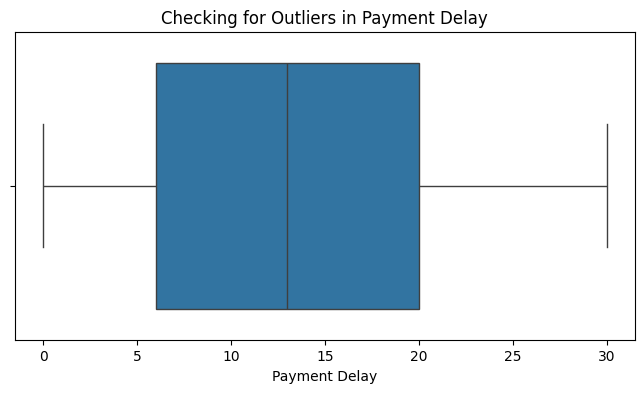

In [18]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Payment Delay'])
plt.title('Checking for Outliers in Payment Delay')
plt.show()

# Splitting the dataset

In [27]:
cols_to_drop = ['CustomerID', 'Churn']
X = df_encoded.drop(columns=cols_to_drop)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
            X, y,  
            test_size=0.2, 
            random_state=42, 
            stratify=y 
        )

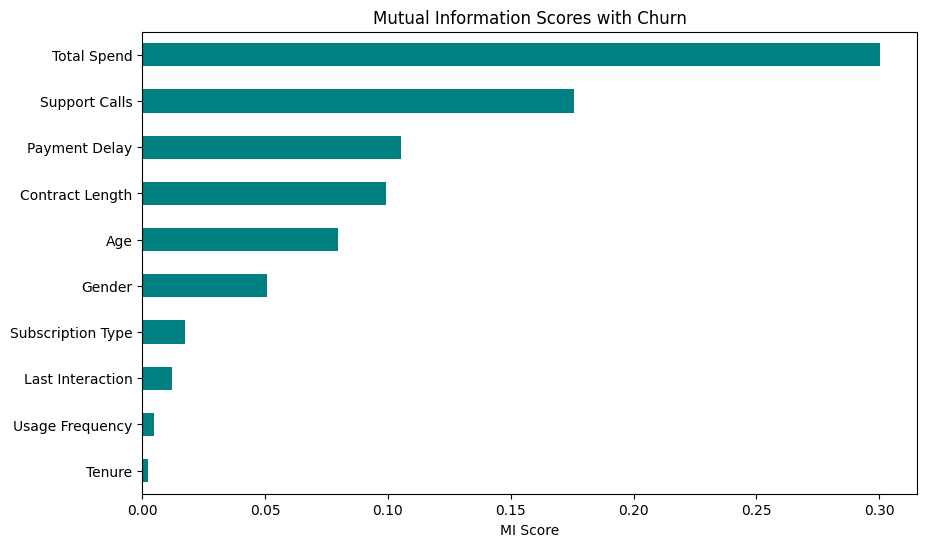

In [28]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import pandas as pd

# Calculate MI scores
importances = mutual_info_classif(X_train, y_train)
feature_importances = pd.Series(importances, index=X.columns)

# Visualize the scores
plt.figure(figsize=(10, 6))
feature_importances.sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('Mutual Information Scores with Churn')
plt.xlabel('MI Score')
plt.show()

# Model training

In [ ]:
# feature_store.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

class FeatureStore:
    def __init__(self, train_path, test_path):
        
        print("--- Concatenating datasets ---")
        df_train = pd.read_csv(train_path)
        df_test = pd.read_csv(test_path)
        
        self.data = pd.concat([df_train, df_test], axis=0)
        self.data.reset_index(drop=True, inplace=True)
        
        
        self.data = self.data.dropna()
        
        
        print("--- Preprocessing features ---")
        self._preprocess()
        
    def _preprocess(self):
        
        categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']
        self.data = pd.get_dummies(self.data, columns=categorical_cols, drop_first=True)
        
        # Calculate LTV
        self.data['Tenure_Safe'] = self.data['Tenure'].replace(0, 1) 
        self.data['Monthly_Spend'] = self.data['Total Spend'] / self.data['Tenure_Safe']
        self.data['LTV_Risk_12_Months'] = self.data['Monthly_Spend'] * 12
        
    def get_train_test_splits(self, test_size=0.20):
        
        cols_to_drop = ['CustomerID', 'Churn', 'Tenure_Safe']
        X = self.data.drop(columns=cols_to_drop)
        y = self.data['Churn']
        customer_ids = self.data['CustomerID']

        X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
            X, y, customer_ids, 
            test_size=test_size, 
            random_state=42, 
            stratify=y 
        )
        
        return X_train, X_test, y_train, y_test, ids_test

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import warnings

warnings.filterwarnings('ignore')

def optimize_and_train(X, y):
    def objective(trial):
        # Hyperparameters for Random Forest
        rf_n_estimators = trial.suggest_int('rf_n_estimators', 50, 150)
        rf_max_depth = trial.suggest_int('rf_max_depth', 3, 6) # Capped at 6 to prevent overfitting
        
        # Hyperparameters for XGBoost
        xgb_learning_rate = trial.suggest_float('xgb_learning_rate', 1e-3, 0.05, log=True) # Lower max rate
        xgb_max_depth = trial.suggest_int('xgb_max_depth', 3, 5) # Capped at 5
        
        # Instantiate models
        rf = RandomForestClassifier(
            n_estimators=rf_n_estimators, 
            max_depth=rf_max_depth, 
            class_weight='balanced', # Automatically handles churn class imbalance
            random_state=42
        )
        xgb = XGBClassifier(
            learning_rate=xgb_learning_rate, 
            max_depth=xgb_max_depth, 
            eval_metric='logloss', 
            random_state=42
        )
        
        # Create Ensemble
        ensemble = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb)], voting='soft')
        
        # Optimizing for F1-Score
        score = cross_val_score(ensemble, X, y, cv=3, scoring='f1').mean()
        return score

    # Run Optuna Study
    print("--- Starting Optuna hyperparameter tuning ---")
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)
    
    print(f"\n--- Best trial F1-Score: {study.best_value:.4f} ---")
    
    # Train final model with best params
    best_rf = RandomForestClassifier(
        n_estimators=study.best_params['rf_n_estimators'], 
        max_depth=study.best_params['rf_max_depth'],
        class_weight='balanced',
        random_state=42
    )
    best_xgb = XGBClassifier(
        learning_rate=study.best_params['xgb_learning_rate'], 
        max_depth=study.best_params['xgb_max_depth'],
        eval_metric='logloss',
        random_state=42
    )
    
    final_ensemble = VotingClassifier(estimators=[('rf', best_rf), ('xgb', best_xgb)], voting='soft')
    final_ensemble.fit(X, y)
    
    return final_ensemble

In [ ]:
# main.py
# from feature_store import FeatureStore
# from model_pipeline import optimize_and_train
from sklearn.metrics import classification_report
import pandas as pd

# Initialize Feature Store
train_file = 'data/customer_churn_dataset-training-master.csv'
test_file = 'data/customer_churn_dataset-testing-master.csv'
store = FeatureStore(train_path=train_file, test_path=test_file)

# Split data
X_train, X_test, y_train, y_test, test_customer_ids = store.get_train_test_splits(test_size=0.20)

# Train the Model 
model = optimize_and_train(X_train, y_train)

# Evaluate
print("\n--- Evaluating Model on 20% Test Set ---")
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

# Check Feature Importances for Data Leakage
xgb_model = model.named_estimators_['xgb']
feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)

print("\nTop 5 Most Important Features:")
print(feature_importances.sort_values(ascending=False).head(5))
print("-" * 50)

Concatenating datasets...
Preprocessing features...
Splitting data: 80% Train / 20% Test...


[I 2026-04-04 13:42:50,073] A new study created in memory with name: no-name-9351a5d4-86f9-4aeb-a05f-60a732d4e32a


Starting Optuna hyperparameter tuning (Optimizing for F1-Score)...


[I 2026-04-04 13:43:41,827] Trial 0 finished with value: 0.9290891846042335 and parameters: {'rf_n_estimators': 92, 'rf_max_depth': 5, 'xgb_learning_rate': 0.001732712234428896, 'xgb_max_depth': 4}. Best is trial 0 with value: 0.9290891846042335.
[I 2026-04-04 13:44:06,943] Trial 1 finished with value: 0.9285121088033991 and parameters: {'rf_n_estimators': 63, 'rf_max_depth': 3, 'xgb_learning_rate': 0.01982077619378053, 'xgb_max_depth': 4}. Best is trial 0 with value: 0.9290891846042335.
[I 2026-04-04 13:45:18,427] Trial 2 finished with value: 0.9256629377111117 and parameters: {'rf_n_estimators': 130, 'rf_max_depth': 5, 'xgb_learning_rate': 0.0070268935803342045, 'xgb_max_depth': 3}. Best is trial 0 with value: 0.9290891846042335.
[I 2026-04-04 13:46:11,291] Trial 3 finished with value: 0.9290627157513441 and parameters: {'rf_n_estimators': 116, 'rf_max_depth': 4, 'xgb_learning_rate': 0.010184892817228005, 'xgb_max_depth': 5}. Best is trial 0 with value: 0.9290891846042335.
[I 2026-04


✅ Best trial F1-Score: 0.9293

--- Evaluating Model on 20% Test Set ---
              precision    recall  f1-score   support

         0.0       0.95      0.86      0.90     44943
         1.0       0.90      0.97      0.93     56099

    accuracy                           0.92    101042
   macro avg       0.92      0.91      0.92    101042
weighted avg       0.92      0.92      0.92    101042


🚨 Top 5 Most Important Features:
Support Calls              0.339235
Contract Length_Monthly    0.276329
Total Spend                0.246138
Age                        0.061608
Payment Delay              0.056043
dtype: float32
--------------------------------------------------


# Sample dashboard

In [26]:
# dashboard.py
from rich.console import Console
from rich.table import Table
# from feature_store import FeatureStore
# from model_pipeline import optimize_and_train

console = Console()

def generate_dashboard(at_risk_customers_df):
    console.print("\n[bold white] Dynamic Revenue Recovery Dashboard[/bold white]\n")
    
    table = Table(show_header=True, header_style="bold white")
    table.add_column("Customer ID", width=15)
    table.add_column("Churn Probability", justify="right")
    table.add_column("Predicted LTV", justify="right")
    table.add_column("Revenue at Risk", style="red white", justify="right")
    
    total_risk = 0
    
    for _, row in at_risk_customers_df.iterrows():
        # Only showing high-risk accounts (> 70% probability)
        if row['Churn_Prob'] > 0.70:
            risk_amount = row['LTV']
            total_risk += risk_amount
            table.add_row(
                str(row['CustomerID']),
                f"{row['Churn_Prob'] * 100:.1f}%",
                f"${row['LTV']:,.2f}",
                f"${risk_amount:,.2f}"
            )
            
    console.print(table)
    console.print(f"\n[bold white] Total Pipeline Revenue at Risk: ${total_risk:,.2f}[/bold white]\n")

# --- Mock Execution ---
import pandas as pd
mock_data = pd.DataFrame({
    'CustomerID': ['CUST-001', 'CUST-002', 'CUST-003'],
    'Churn_Prob': [0.85, 0.20, 0.92],
    'LTV': [45000, 12000, 89000]
})

if __name__ == "__main__":
    generate_dashboard(mock_data)

 Dynamic Revenue Recovery Dashboard

┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Customer ID     ┃ Churn Probability ┃ Predicted LTV ┃ Revenue at Risk ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ CUST-001        │             85.0% │    $45,000.00 │      $45,000.00 │
│ CUST-003        │             92.0% │    $89,000.00 │      $89,000.00 │
└─────────────────┴───────────────────┴───────────────┴─────────────────┘

 Total Pipeline Revenue at Risk: $134,000.00